<a href="https://colab.research.google.com/github/mohamed0barhoomi/Final_DATASC_Project/blob/main/last_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler,LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from  sklearn.cluster import KMeans,MiniBatchKMeans,AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,davies_bouldin_score
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.neighbors import NearestNeighbors

In [2]:
data=pd.read_csv("dataset.csv", sep=",")
print(data.columns)
print(data.head())

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41791 entries, 0 to 41790
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        41791 non-null  int64  
 1   track_id          41791 non-null  object 
 2   artists           41791 non-null  object 
 3   album_name        41791 non-null  object 
 4   track_name        41791 non-null  object 
 5   popularity        41791 non-null  int64  
 6   duration_ms       41791 non-null  int64  
 7   explicit          41791 non-null  bool   
 8   danceability      41791 non-null  float64
 9   energy            41791 non-null  float64
 10  key               41791 non-null  int64  
 11  loudness          41791 non-null  float64
 12  mode              41791 non-null  int64  
 13  speechiness       41791 non-null  float64
 14  acousticness      41791 non-null  float64
 15  instrumentalness  41791 non-null  float64
 16  liveness          41791 non-null  float6

In [4]:
data.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,41791.000000,41791.000000,4.179100e+04,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41791.000000,41790.000000
mean,20895.000000,33.362686,2.321330e+05,0.576327,0.640524,5.326721,-8.295916,0.632672,0.095367,0.302711,0.182286,0.207010,0.462767,122.526675,3.915363
std,12064.166887,22.022526,1.222714e+05,0.174290,0.247246,3.564605,5.065944,0.482083,0.140589,0.328225,0.326735,0.185439,0.258645,28.876139,0.402487
min,0.000000,0.000000,1.745300e+04,0.000000,0.000020,0.000000,-42.044000,0.000000,0.000000,0.000000,0.000000,0.011200,0.000000,0.000000,0.000000
25%,10447.500000,17.000000,1.734535e+05,0.464000,0.481000,2.000000,-9.974000,0.000000,0.036000,0.015200,0.000000,0.096400,0.245000,100.552000,4.000000
50%,20895.000000,35.000000,2.132660e+05,0.590000,0.682000,5.000000,-7.014000,1.000000,0.048700,0.155000,0.000102,0.128000,0.446000,122.974000,4.000000
75%,31342.500000,50.000000,2.658330e+05,0.706000,0.845000,8.000000,-5.070500,1.000000,0.084900,0.568000,0.154000,0.259000,0.668000,139.964000,4.000000
max,41790.000000,100.000000,4.789026e+06,0.983000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,0.995000,0.995000,0.995000,243.372000,5.000000


In [5]:
data.isna().sum()[data.isna().sum()>0]

,0
time_signature,1
track_genre,1


In [6]:
data=data.dropna()

print("shape after drop : ",data.shape)

shape after drop :  (41790, 21)


In [7]:
data = data.drop(columns=["Unnamed: 0"])
print("dupliquate in track id : ",data["track_id"].duplicated().sum())
data=data.drop_duplicates(subset="track_id", keep="first").copy()
print("demention after delete dupliquate music track and unamed col (col of index )",data.shape)

dupliquate in track id :  4518
demention after delete dupliquate music track and unamed col (col of index ) (37272, 20)


In [8]:
num_col=[col for col in data.columns if data[col].dtype == "int64" or data[col].dtype == "float64"]
categ_col=[col for col in data.columns if data[col].dtype == "object"]

In [9]:
three_shold=3
for col in num_col:
   z_score=np.abs(stats.zscore(data[col]))
   ouliers=data[z_score>three_shold]
   print("outliers in col {} : {}".format(col,len(ouliers)/data.shape[0]))

outliers in col popularity : 5.365958360163125e-05
outliers in col duration_ms : 0.00853187379265937
outliers in col danceability : 0.0001073191672032625
outliers in col energy : 0.0
outliers in col key : 0.0
outliers in col loudness : 0.022295556986477786
outliers in col mode : 0.0
outliers in col speechiness : 0.024254131787937325
outliers in col acousticness : 0.0
outliers in col instrumentalness : 0.0
outliers in col liveness : 0.030934749946340417
outliers in col valence : 0.0
outliers in col tempo : 0.0006975745868212063
outliers in col time_signature : 0.008692852543464262


In [10]:
print("nombre of genre",data["track_genre"].nunique())
print("nobre of artist",data["artists"].nunique())
print("nb of artist par genre : {}".format(round(data["artists"].nunique()/data["track_genre"].nunique(),2)))


nombre of genre 42
nobre of artist 14407
nb of artist par genre : 343.02


In [11]:
sns.set_style("whitegrid")

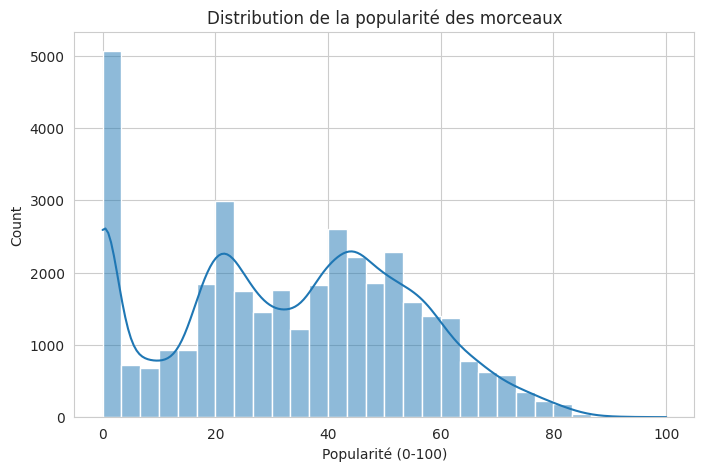

In [12]:

plt.figure(figsize=(8,5))
sns.histplot(data["popularity"],bins=30,kde=True)
plt.title("Distribution de la popularité des morceaux")
plt.xlabel("Popularité (0-100)")
plt.show()

track_genre
chill         53.738683
anime         48.776884
emo           48.500000
deep-house    45.573045
british       44.768889
brazil        44.645678
electronic    44.234940
ambient       44.208208
acoustic      42.483000
forro         41.831663
french        41.089888
garage        40.611543
edm           40.439481
dub           40.325831
folk          40.164090
Name: popularity, dtype: float64


Text(0.5, 0, 'popularity moy')

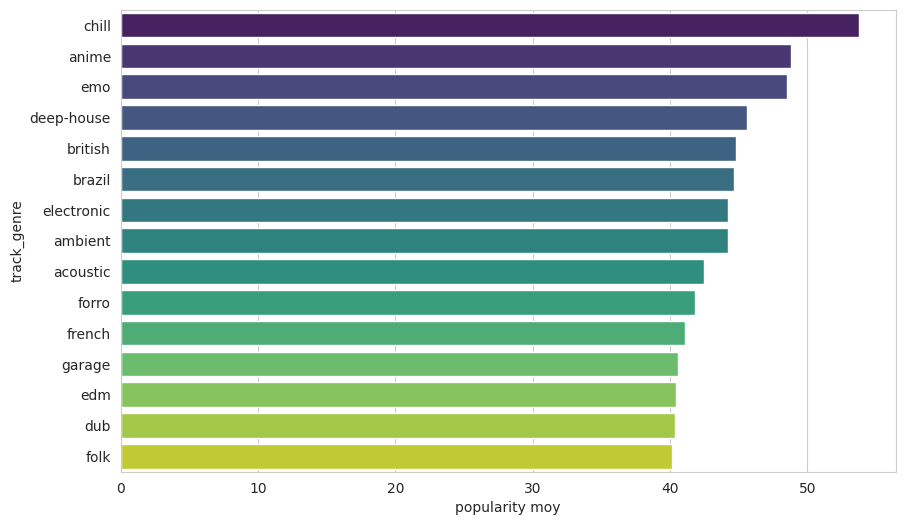

In [13]:
genre_popul=data.groupby(["track_genre"])["popularity"].mean().sort_values(ascending=False).head(15)
print(genre_popul)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_popul.values,y=genre_popul.index,hue=genre_popul.index, palette="viridis", legend=False)
plt.xlabel("popularity moy")

artists
Ariana Grande       80.777778
Foo Fighters        79.000000
System Of A Down    78.600000
MGMT                77.500000
Billy Joel          77.000000
Name: popularity, dtype: float64


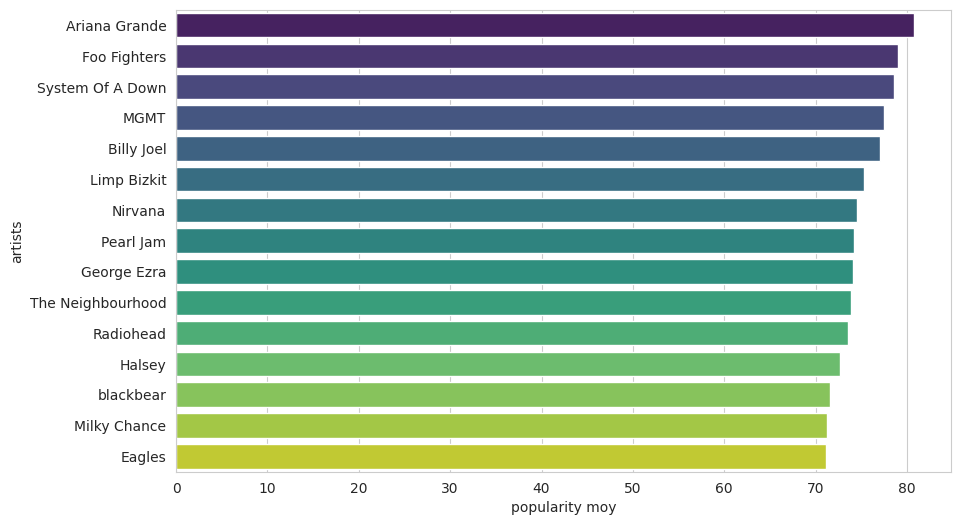

In [14]:
artist_count=data["artists"].value_counts()
principale_art=artist_count[artist_count>3].index

top_artist=(data[data["artists"].isin(principale_art)].groupby("artists")["popularity"].mean().sort_values(ascending=False).head(15))
print(top_artist.head())
plt.figure(figsize=(10,6))
sns.barplot(x=top_artist.values,y=top_artist.index,hue=top_artist.index,palette="viridis", legend=False)
plt.xlabel("popularity moy")
plt.show()

In [15]:
audio_feature = ["danceability", "energy", "valence", "acousticness", "speechiness", "tempo"]
top_genre=genre_popul.head(10).index
print(top_genre)
genre_porc=data[data["track_genre"].isin(top_genre)].groupby("track_genre")[audio_feature].mean()
print(genre_porc)

Index(['chill', 'anime', 'emo', 'deep-house', 'british', 'brazil',
       'electronic', 'ambient', 'acoustic', 'forro'],
      dtype='object', name='track_genre')
             danceability    energy   valence  acousticness  speechiness  \
track_genre                                                                
acoustic         0.549593  0.435368  0.424023      0.566816     0.043247   
ambient          0.367966  0.237257  0.167345      0.776701     0.041553   
anime            0.537666  0.674229  0.434644      0.267117     0.087429   
brazil           0.563674  0.611685  0.460765      0.340749     0.096897   
british          0.503564  0.501523  0.434525      0.429989     0.050763   
chill            0.666423  0.429531  0.408306      0.530572     0.103493   
deep-house       0.710730  0.741378  0.446909      0.103161     0.059698   
electronic       0.658045  0.691047  0.396058      0.178887     0.079349   
emo              0.601147  0.667745  0.441194      0.191794     0.112685   
f

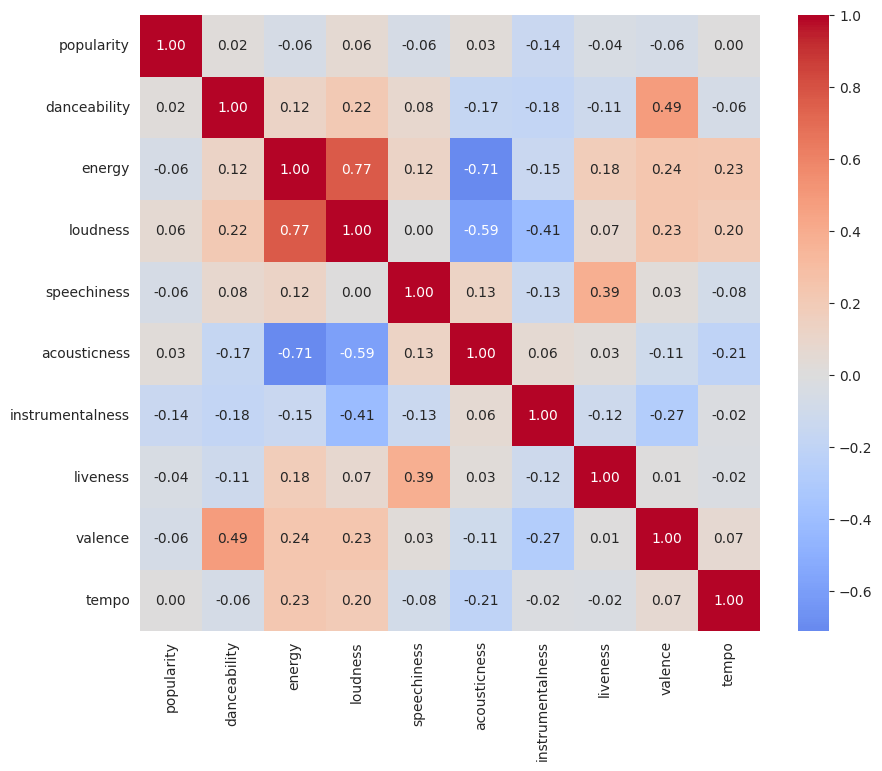

In [16]:
corr_features = ["popularity","danceability","energy","loudness","speechiness",
                  "acousticness","instrumentalness","liveness","valence","tempo"]
plt.figure(figsize=(10,8))
sns.heatmap(data[corr_features].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.show()

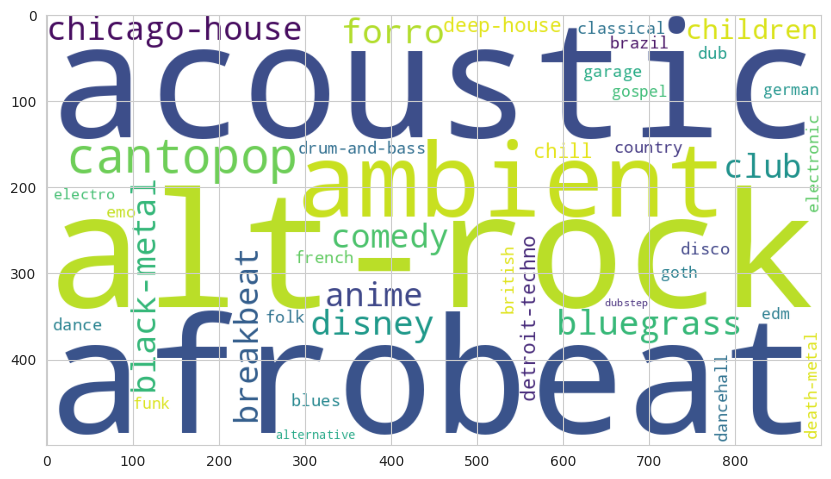

In [17]:
genre_fr = data["track_genre"].value_counts().to_dict()

wc_genre = WordCloud(width=900, height=500,background_color="white",colormap="viridis").generate_from_frequencies(genre_fr)
plt.figure(figsize=(10,10))
plt.imshow(wc_genre)
plt.show()

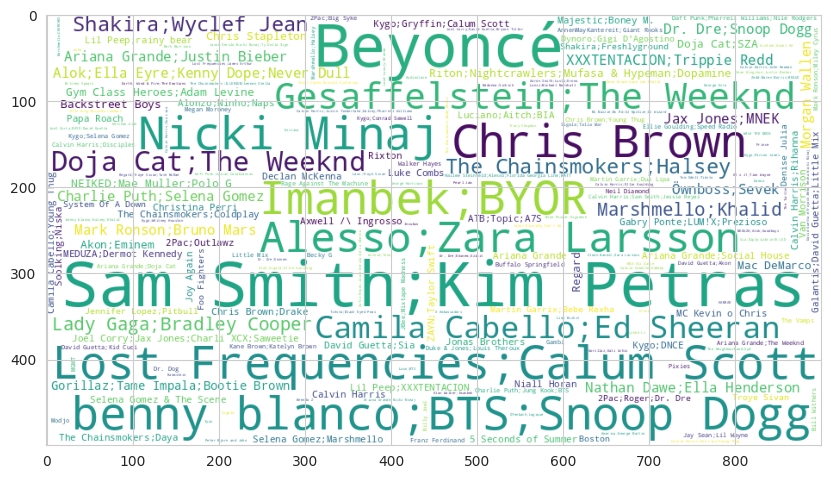

In [18]:
artist_fr=data.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(200).to_dict()
wc_artist = WordCloud(width=900, height=500, background_color="white",
                       colormap="viridis").generate_from_frequencies(artist_fr)
plt.figure(figsize=(10,10))
plt.imshow(wc_artist)
plt.show()

In [19]:
fut_princ=["danceability", "energy", "loudness", "speechiness","acousticness", "instrumentalness", "liveness","valence", "tempo"]
princ_data=data[fut_princ].copy()
print(princ_data.head())
scaler=StandardScaler()
princ_data=scaler.fit_transform(princ_data)
print(data.isna().sum())
data=data.dropna()


   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  liveness  valence    tempo  
0          0.000001    0.3580    0.715   87.917  
1          0.000006    0.1010    0.267   77.489  
2          0.000000    0.1170    0.120   76.332  
3          0.000071    0.1320    0.143  181.740  
4          0.000000    0.0829    0.167  119.949  
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrum

In [20]:
inertie=[]
for k in range(2,13):
    km=KMeans(n_clusters=k,random_state=42, n_init=10)
    km.fit(princ_data)
    inertie.append(km.inertia_)
print(inertie)

[266401.7698130976, 230295.51687011868, 199893.05564283812, 179618.52598903535, 162866.08672704673, 149840.60744253566, 141057.09460122013, 135130.44819816377, 129901.88724190884, 125070.30435920098, 120891.20959748169]


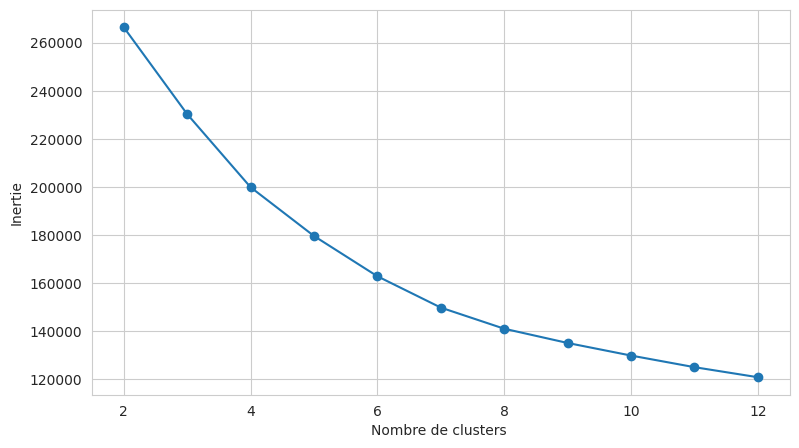

In [21]:
plt.figure(figsize=(9,5))
plt.plot(list(range(2,13)), inertie, marker="o")
plt.xlabel("Nombre de clusters ")
plt.ylabel("Inertie")
plt.show()

In [22]:
part_indx = np.random.RandomState(42).choice(len(princ_data), size=5000, replace=False)
part_data = princ_data[part_indx]
print(princ_data.shape)
print(part_data.shape)

(37272, 9)
(5000, 9)


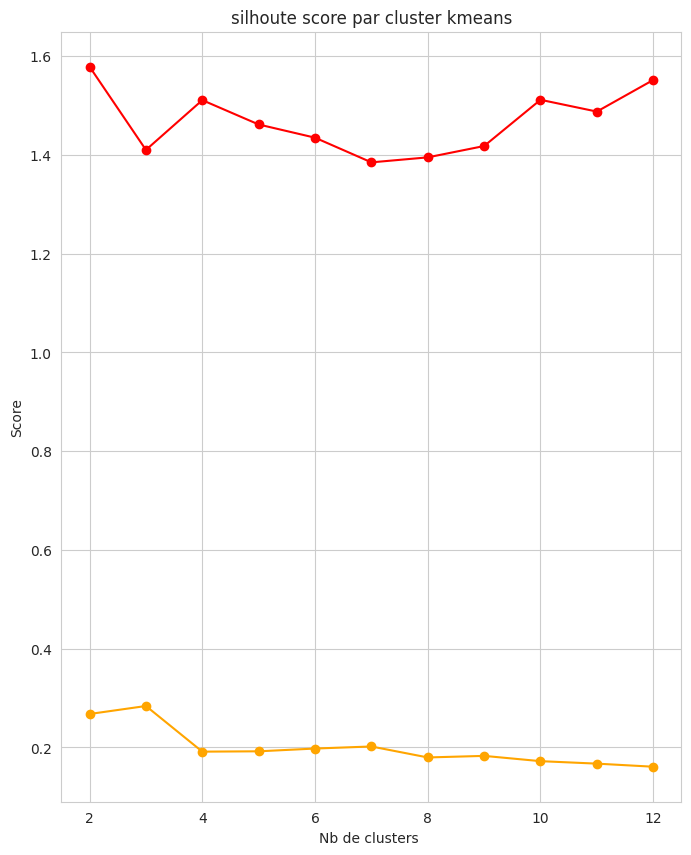

In [23]:
sil_scores = []
DVB=[]
for k in range(2,13):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred = km.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,10))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)), DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster kmeans")
plt.show()

In [24]:
print("silhoutte de k=8 :",sil_scores[6])
print("DVB de k=8 : ",DVB[6])

silhoutte de k=8 : 0.17980481332114476
DVB de k=8 :  1.3949885761816647


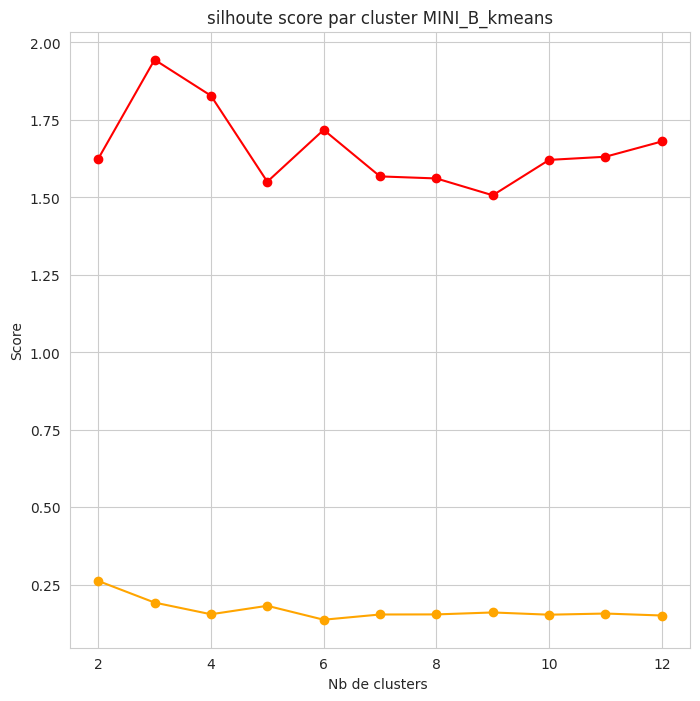

In [25]:
sil_scores = []
DVB=[]
for k in range(2,13):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=500)
    pred = km.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,8))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)), DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster MINI_B_kmeans")
plt.show()

In [26]:
print("silhoutte de k=8 :", sil_scores[6])
print("DVB de k=8 : ", DVB[6])

silhoutte de k=8 : 0.15472551898425094
DVB de k=8 :  1.5611537346242204


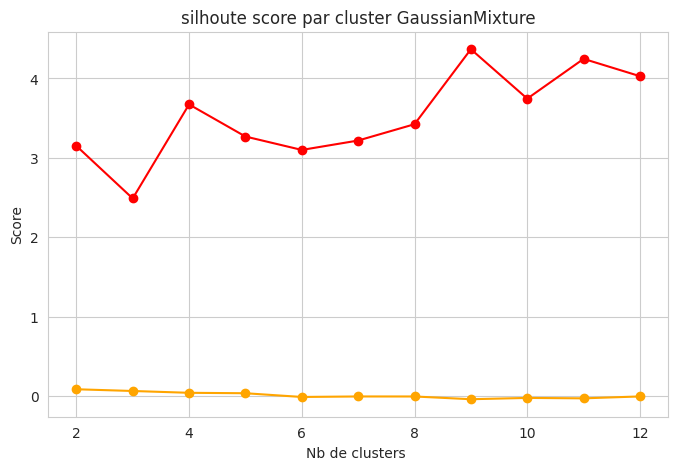

In [27]:
sil_scores = []
DVB=[]
for k in range(2,13):
    Gm = GaussianMixture( n_components=k,covariance_type='full',random_state=42)
    pred = Gm.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))

plt.figure(figsize=(8,5))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)), DVB, marker="o", color="red")

plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster GaussianMixture")
plt.show()

In [28]:
print("silhoutte de k=8 :",sil_scores[6])
print("DVB de k=8 : ",DVB[6])

silhoutte de k=8 : -0.007004749300222062
DVB de k=8 :  3.4231717506586117


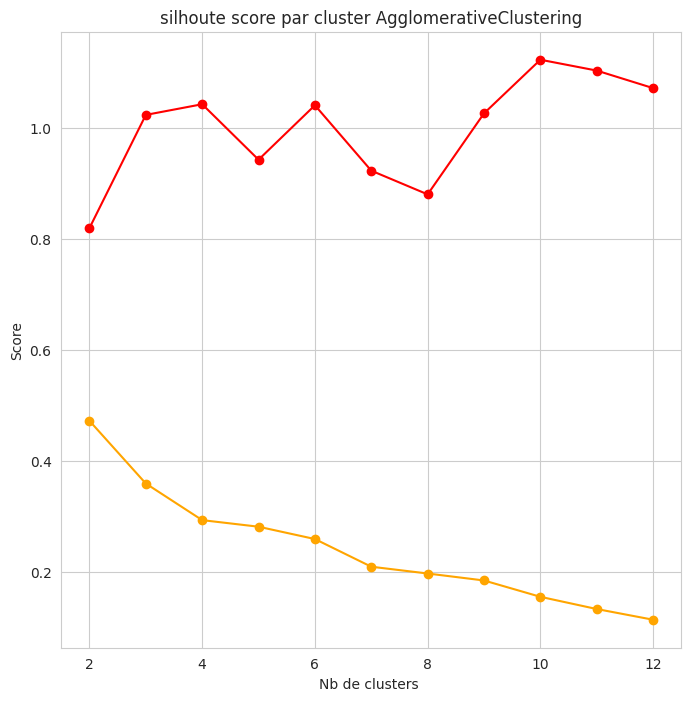

In [29]:
sil_scores = []
DVB=[]
for k in range(2,13):
    agg = AgglomerativeClustering(n_clusters=k, linkage='average')
    pred = agg.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,8))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)),DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster AgglomerativeClustering")
plt.show()

In [30]:
print("silhoutte de k=8 :",sil_scores[4])
print("DVB de k=8 : ",DVB[4])

silhoutte de k=8 : 0.2588301557454477
DVB de k=8 :  1.0403602485967867


In [31]:
sil_scores = []
DVB=[]
model = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
pred = model.fit_predict(part_data)
sil_scores.append(silhouette_score(part_data, pred))
DVB.append(davies_bouldin_score(part_data, pred))
print("silhoutte de k=8 :",sil_scores[0])
print("DVB de k=8 : ",DVB[0])

silhoutte de k=8 : 0.3612631740379625
DVB de k=8 :  1.8975167554661596


In [32]:
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
k_KM=8

In [33]:
# k_agg=6
# pred=[]
# pred_agg=pd.DataFrame(pred)
# agg_model = AgglomerativeClustering(n_clusters=k_agg, linkage='average')
# pred_agg["cluster"]=agg_model.fit_predict(princ_data)
# print(pred_agg.value_counts().sort_values(ascending=False))


# i can't use this model !!!!!!!!!!!!!!!!!!!!! cause of memory

In [34]:

genre_df = pd.read_csv("data_by_genres.csv")
print("Shape original :", genre_df.shape)

genre_df = genre_df[genre_df["genres"].str.strip() != "[]"].copy()
genre_df = genre_df.dropna(subset=["genres"]).reset_index(drop=True)
print("Shape après nettoyage :", genre_df.shape)
genre_df.head()

Shape original : (2973, 14)
Shape après nettoyage : (2972, 14)


,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,1,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,1,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,1,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1


In [35]:
scaler_genre = StandardScaler()
data_genre = scaler_genre.fit_transform(genre_df[fut_princ])
print(data_genre)

[[-2.48432022 -2.08926443 -3.91221519 ...  1.82784035 -1.92725355
  -2.5007007 ]
 [-1.57868449 -0.47132341 -1.18171535 ... -0.66906228 -1.34273793
   0.07240734]
 [ 1.16023582  1.09526817  0.24757383 ... -0.72320154  2.38955698
   0.82565408]
 ...
 [ 1.405072    0.26124254  0.04098022 ... -1.11649318  1.64191432
  -0.97634365]
 [ 1.1182007  -1.65701643 -0.17583648 ... -0.14210683  1.22019541
  -1.58813202]
 [ 0.61206723  0.20547723  0.12188701 ...  0.6830829   1.56477877
   0.42048007]]


In [36]:
km_genre = KMeans(n_clusters=8, random_state=42, n_init=10)
genre_df["cluster"] = km_genre.fit_predict(data_genre)

print("nbr des genres par cluster :")
print(genre_df["cluster"].value_counts().sort_index())

nbr des genres par cluster :
cluster
0    588
1    780
2    363
3    254
4    653
5     67
6    246
7     21
Name: count, dtype: int64


In [37]:
CLUSTER_NAME = {
    0:  "Electronic & Chill Instrumentals",
    1:  "Peaceful Acoustic & Classical",
    2:  "Feel-Good Dance & Pop",
    3:  "Heavy Punk & Metal",
    4:  "Hip-Hop & Dance Beats",
    5:  "Comedy & Spoken Audio",
    6:  "Relaxing Classical Instrumentals",
    7:  "Hard Rock & Heavy Metal"
}

genre_df["cluster_name"] = genre_df["cluster"].map(CLUSTER_NAME)

for c, name in CLUSTER_NAME.items():
    count = (genre_df["cluster"] == c).sum()
    sample_genres = genre_df[genre_df["cluster"] == c]["genres"].tolist()[:4]
    print(f"Cluster {c:2d} : {name:<40} nbr genre : {count:4d} genres | ex: {','.join(sample_genres)}")

Cluster  0 : Electronic & Chill Instrumentals         nbr genre :  588 genres | ex: acid rock,action rock,adoracion,african percussion
Cluster  1 : Peaceful Acoustic & Classical            nbr genre :  780 genres | ex: abstract beats,acoustic punk,afghan pop,african reggae
Cluster  2 : Feel-Good Dance & Pop                    nbr genre :  363 genres | ex: 21st century classical,432hz,acousmatic,african-american classical
Cluster  3 : Heavy Punk & Metal                       nbr genre :  254 genres | ex: 8-bit,abstract,acid house,acid trance
Cluster  4 : Hip-Hop & Dance Beats                    nbr genre :  653 genres | ex: a cappella,accordeon,accordion,acoustic blues
Cluster  5 : Comedy & Spoken Audio                    nbr genre :   67 genres | ex: arabic hip hop,atmospheric post-metal,atmospheric sludge,australian underground hip hop
Cluster  6 : Relaxing Classical Instrumentals         nbr genre :  246 genres | ex: abstract hip hop,afro dancehall,afro soul,afrofuturism
Cluster  7 :

In [38]:
profile = genre_df.groupby("cluster_name")[fut_princ + ["popularity"]].mean().round(3)
profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
cluster_name,,,,,,,,,,
Comedy & Spoken Audio,0.504,0.594,-10.642,0.093,0.459,0.326,0.577,0.474,113.569,33.247
Electronic & Chill Instrumentals,0.457,0.793,-6.470,0.079,0.105,0.118,0.212,0.415,132.945,45.079
Feel-Good Dance & Pop,0.327,0.172,-21.252,0.051,0.877,0.603,0.153,0.229,103.703,31.259
Hard Rock & Heavy Metal,0.604,0.377,-16.903,0.763,0.723,0.025,0.387,0.457,102.264,13.306
Heavy Punk & Metal,0.551,0.679,-9.507,0.063,0.172,0.617,0.183,0.407,121.644,38.163
Hip-Hop & Dance Beats,0.526,0.377,-12.336,0.064,0.693,0.156,0.181,0.505,114.356,31.342
Peaceful Acoustic & Classical,0.644,0.651,-8.234,0.066,0.283,0.065,0.174,0.668,119.417,45.618
Relaxing Classical Instrumentals,0.719,0.671,-7.130,0.209,0.200,0.033,0.185,0.576,119.675,51.044


In [39]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(data_genre)

genre_df["tsne_1"] = tsne_result[:, 0]
genre_df["tsne_2"] = tsne_result[:, 1]

In [40]:

fig_genre = px.scatter(
    genre_df,
    x="tsne_1",
    y="tsne_2",
    color="cluster_name",
    hover_name="genres",
    hover_data={
        "cluster_name":   True,
        "popularity":     ":.1f",
        "danceability":   ":.3f",
        "energy":         ":.3f",
        "valence":        ":.3f",
        "acousticness":   ":.3f",
        "tempo":          ":.1f",
        "tsne_1":         False,
        "tsne_2":         False,
    },
    title="<b>Clustering des Genres Musicaux using T-SNE with k=8</b>",
    labels={"color": "Groupe"},
    color_discrete_sequence=px.colors.qualitative.Set3,
    width=1000,
    height=700,
)
fig_genre.update_traces(marker=dict(size=7, line=dict(width=0.5, color="white")))
fig_genre.update_layout(
    title_font_size=16,
    legend_title_text="Groupe musical",
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(font=dict(size=11)),
)
fig_genre.show()

In [41]:
data_songs = scaler.fit_transform(data[fut_princ])
print(f"Données chansons standardisées : {data_songs.shape}")

Données chansons standardisées : (37272, 9)


In [42]:
km_songs = KMeans(n_clusters=25, random_state=42, n_init=10)
data = data.copy()
data["cluster"] = km_songs.fit_predict(data_songs)

print("Distribution des chansons par cluster :")
print(data["cluster"].value_counts().sort_index())

Distribution des chansons par cluster :
cluster
0     1743
1     1609
2     1025
3      906
4      833
5     1944
6     1876
7     1548
8     2004
9     1172
10    2143
11    1931
12     958
13    1057
14     905
15    1546
16     642
17    2787
18    1706
19     950
20    1867
21    1462
22     919
23     848
24    2891
Name: count, dtype: int64


In [43]:
SONG_CLUSTER_NAMES = {
    0:  "Chill Study & Instrumental Guitar",
    1:  "Electronic Dance & EDM",
    2:  "Disco, Latin & Dance Floor",
    3:  "Asian & Bollywood Pop",
    4:  "Sleep, Piano & Deep Ambient",
    5:  "Energetic Pop & Punk (J-Idol / Ska)",
    6:  "Comedy, Kids & Show Tunes",
    7:  "Tango, Country & Acoustic Romance",
    8:  "World Music, Dub & Gospel",
    9:  "Brazilian Music (Samba / Pagode)",
    10: "Opera, Jazz & Disney Classics",
    11: "Heavy Metal & Grunge",
    12: "J-Dance, Hardstyle & Dancehall",
    13: "New Age, Persian & Ambient Classical",
    14: "Soft Asian Pop & Acoustic Romance",
    15: "Extreme Energy (Hardstyle / DnB / Metal)",
    16: "Extreme Metal (Black / Death / Grind)",
    17: "Folk, Salsa & Country Roots",
    18: "Dancehall, Funk & Kids Party",
    19: "Energetic Live World & Metal Mix",
    20: "Techno, Trance & IDM",
    21: "Salsa, Rock-n-Roll & Bluegrass",
    22: "House, Afrobeat & Breakbeat",
    23: "Party & High Energy Pop",
    24: "Dark Sleep & World Ambient",
}


data["cluster_name"] = data["cluster"].map(SONG_CLUSTER_NAMES)

for c, name in SONG_CLUSTER_NAMES.items():
    count = (data["cluster"] == c).sum()
    # ✅ Erreur 2 corrigée : track_genre au lieu de track_name (tu voulais afficher des genres, pas des titres)
    sample_genres = data[data["cluster"] == c]["track_genre"].tolist()[:4]
    print(f"Cluster {c:2d} : {name:<42} | nbr songs : {count:5d} | ex: {', '.join(sample_genres)}")

Cluster  0 : Chill Study & Instrumental Guitar          | nbr songs :  1743 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  1 : Electronic Dance & EDM                     | nbr songs :  1609 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  2 : Disco, Latin & Dance Floor                 | nbr songs :  1025 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  3 : Asian & Bollywood Pop                      | nbr songs :   906 | ex: acoustic, acoustic, acoustic, ambient
Cluster  4 : Sleep, Piano & Deep Ambient                | nbr songs :   833 | ex: afrobeat, afrobeat, afrobeat, ambient
Cluster  5 : Energetic Pop & Punk (J-Idol / Ska)        | nbr songs :  1944 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  6 : Comedy, Kids & Show Tunes                  | nbr songs :  1876 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  7 : Tango, Country & Acoustic Romance          | nbr songs :  1548 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  8 : World Music, Dub & Go

In [44]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(data_songs)

data["pca_1"] = pca_result[:, 0]
data["pca_2"] = pca_result[:, 1]

print(f"Variance expliquée par les 2 composantes PCA : {pca.explained_variance_ratio_.sum():.2%}")

sample_viz = data.sample(8000, random_state=42)

fig_songs = px.scatter(
    sample_viz,
    x="pca_1",
    y="pca_2",
    color=sample_viz["cluster"].astype(str),
    hover_name="track_name",
    hover_data={
        "artists":      True,
        "track_genre":  True,
        "popularity":   True,
        "pca_1":        False,
        "pca_2":        False,
        "cluster":      False,
    },
    title="<b>Clustering des Chansons — PCA k=25, échantillon of  8000 ligne</b>",
    labels={"color": "Cluster"},
    color_discrete_sequence=px.colors.qualitative.Alphabet,
    width=1000,
    height=700,
    opacity=0.7,
)
fig_songs.update_traces(marker=dict(size=5))
fig_songs.update_layout(
    title_font_size=16,
    legend_title_text="Cluster",
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig_songs.show()

Variance expliquée par les 2 composantes PCA : 47.61%


In [45]:
song_cluster_profile = data.groupby("cluster")[fut_princ].mean().round(3)
song_cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.433,0.889,-4.957,0.090,0.025,0.058,0.219,0.244,110.753
1,0.509,0.537,-7.851,0.048,0.288,0.024,0.158,0.329,87.798
2,0.588,0.287,-15.764,0.060,0.815,0.823,0.142,0.391,116.181
3,0.340,0.058,-27.527,0.046,0.957,0.844,0.123,0.207,104.729
4,0.559,0.720,-11.040,0.896,0.801,0.003,0.750,0.423,96.996
5,0.411,0.876,-4.550,0.095,0.036,0.035,0.201,0.365,166.026
6,0.601,0.770,-5.830,0.073,0.291,0.017,0.160,0.791,162.997
7,0.470,0.257,-12.992,0.046,0.818,0.027,0.150,0.309,90.878
8,0.580,0.817,-5.155,0.064,0.102,0.017,0.158,0.661,103.256


In [46]:
for c in sorted(data["cluster"].unique())[:10]:
    top_g = data[data["cluster"] == c]["track_genre"].value_counts().head(3)
    print(f"Cluster {c} — top genres : {', '.join(top_g.index.tolist())}")

Cluster 0 — top genres : death-metal, black-metal, goth
Cluster 1 — top genres : folk, cantopop, acoustic
Cluster 2 — top genres : classical, disney, chill
Cluster 3 — top genres : ambient, classical, disney
Cluster 4 — top genres : comedy, children, french
Cluster 5 — top genres : drum-and-bass, dub, black-metal
Cluster 6 — top genres : forro, bluegrass, blues
Cluster 7 — top genres : acoustic, disney, cantopop
Cluster 8 — top genres : alt-rock, dance, garage
Cluster 9 — top genres : acoustic, cantopop, bluegrass


Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'cluster',
       'cluster_name', 'pca_1', 'pca_2'],
      dtype='object')


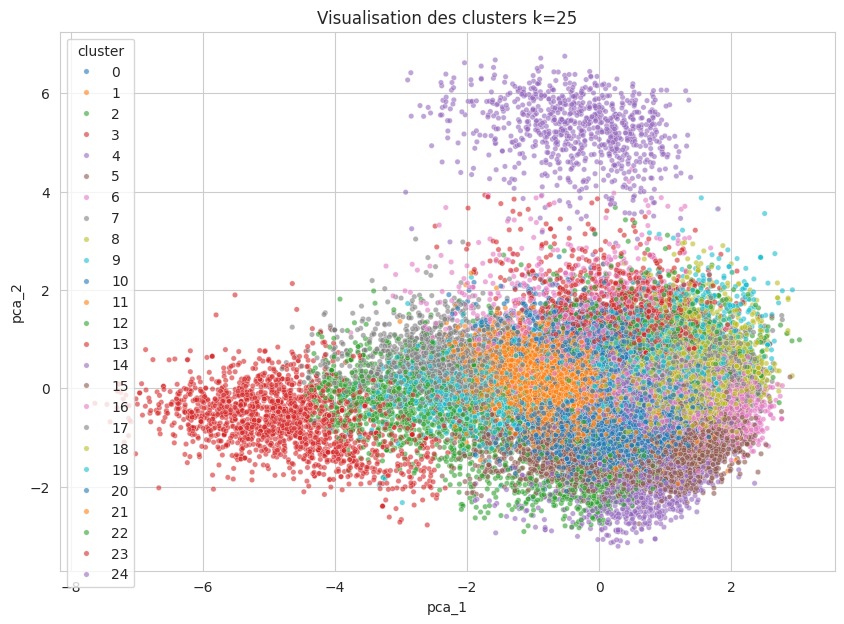

Variance expliquée par les 2 composantes : 47.61%


In [47]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(princ_data)

data["pca_1"] = X_pca[:, 0]
data["pca_2"] = X_pca[:, 1]
print(data.columns)
plt.figure(figsize=(10,7))
sns.scatterplot(data=data, x="pca_1", y="pca_2", hue="cluster",
                 palette="tab10", s=15, alpha=0.6)
plt.title(f"Visualisation des clusters k=25")
plt.show()

print(f"Variance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum():.2%}")

In [48]:
for claster in sorted(data["cluster"].unique()):
    top_genres_cluster = data[data["cluster"] == claster]["track_genre"].value_counts().head(5)
    print(f"\nCluster {claster} — have as genres :")
    print(top_genres_cluster)


Cluster 0 — have as genres :
track_genre
death-metal    408
black-metal    226
goth           109
dub             97
alt-rock        93
Name: count, dtype: int64

Cluster 1 — have as genres :
track_genre
folk        90
cantopop    79
acoustic    77
gospel      77
country     74
Name: count, dtype: int64

Cluster 2 — have as genres :
track_genre
classical    164
disney       132
chill        132
ambient      122
anime        100
Name: count, dtype: int64

Cluster 3 — have as genres :
track_genre
ambient      314
classical    312
disney       138
anime         41
german        35
Name: count, dtype: int64

Cluster 4 — have as genres :
track_genre
comedy      794
children     11
french        5
garage        3
chill         3
Name: count, dtype: int64

Cluster 5 — have as genres :
track_genre
drum-and-bass    268
dub              167
black-metal      152
garage           131
death-metal      130
Name: count, dtype: int64

Cluster 6 — have as genres :
track_genre
forro        391
bluegras

In [49]:
data = data.reset_index(drop=True)
indice = pd.Series(data.index, index=data["track_name"].str.lower())
print(indice)

track_name
comedy                                              0
ghost - acoustic                                    1
to begin again                                      2
can't help falling in love                          3
hold on                                             4
                                                ...  
stolzes herz - single version - radio edit      37267
hoppas att det ska gå bra för de yngre också    37268
asteroid - remastered                           37269
monsters                                        37270
southern son                                    37271
Length: 37272, dtype: int64


In [50]:
nn_model = NearestNeighbors(n_neighbors=11, metric="cosine")
nn_model.fit(data_songs)


NearestNeighbors(metric='cosine', n_neighbors=11)

In [51]:
def recommend_song(track_name, n_recommendations=10):

    if track_name.lower() not in indice.index:
        print(f"Morceau '{track_name}' introuvable dans le dataset.")
        return None

    idx = indice[track_name.lower()]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0] # teke the 1ere songs

    distances, neighbor_idx = nn_model.kneighbors(data_songs[idx].reshape(1, -1), n_neighbors=n_recommendations + 1)


    neighbor_idx = neighbor_idx[0][1:]
    similarity_scores = 1 - distances[0][1:]
    result = data.iloc[neighbor_idx][["track_name","artists", "track_genre","popularity"]].copy()
    result["similarity_score"] = similarity_scores
    return result.reset_index(drop=True)

In [52]:
recommend_song("Comedy", n_recommendations=10)

,track_name,artists,track_genre,popularity,similarity_score
0,Look For The Good (Single Version),Jason Mraz,acoustic,21,0.928426
1,Monde de fous,Danakil,dub,32,0.928351
2,Blink 182,Trille,german,53,0.925679
3,Pop Virus,Gen Hoshino,acoustic,47,0.925117
4,Amigos,Juan Magán;Mariah Angeliq;Yera,electro,0,0.908892
5,Walking in the City,Play School,children,33,0.905629
6,馬と鹿,Kenshi Yonezu,anime,60,0.905603
7,i can't get high,Royal & the Serpent,alternative,1,0.905250
8,Invece No,Disme;Andrews Right,emo,35,0.903315
9,Sonhos Gangsta,Flora Matos,brazil,47,0.900501


In [53]:
!pip install spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.4/502.4 kB 29.3 MB/s eta 0:00:00


In [54]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from collections import defaultdict
from scipy.spatial.distance import cdist
import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [55]:
princ_data

array([[ 0.55347782, -0.7026609 ,  0.32853833, ...,  0.80328378,
         0.95145656, -1.19131766],
       [-0.90627513, -1.88752389, -1.74660914, ..., -0.56955568,
        -0.76923613, -1.55123435],
       [-0.80363625, -1.11234234, -0.26260865, ..., -0.48408708,
        -1.33383842, -1.59116757],
       ...,
       [-0.63827361,  1.35377928,  1.0530297 , ..., -0.08879478,
         0.36765011, -0.47800752],
       [-1.41946953,  0.25727895,  0.366128  , ..., -0.52682138,
        -0.86909776, -1.3273046 ],
       [-0.55274122,  1.27344958,  0.72936288, ..., -0.73461692,
         0.21017601,  0.5015816 ]])

In [56]:
CLIENT_ID = "1eb70895ef614cb2b2451dda5a2064e2"
CLIENT_SECRET = "c7335411fe394b9bacd4c36eb5715531"

# Connexion à API Spotify
sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
)
print("Connecté à l'API Spotify.")

Connecté à l'API Spotify.


In [72]:
def find_song(name):
    if sp is None:
        print("Pas de connexion API.")
        return None

    try:
        query = f"track:{name}"
        results = sp.search(q=query, limit=1, type="track")
        print("Résultat brut de l'API :\n", results)

        if not results["tracks"]["items"]:
            print(f"'{name}' introuvable sur Spotify.")
            return None

        track = results["tracks"]["items"][0]
        track_id = track["id"]
        print(f"Chanson trouvée : '{track['name']}' par {track['artists'][0]['name']}")

        audio_features = sp.audio_features(track_id)[0]
        if audio_features is None:
            return None

        song_data = {
            "track_name": track["name"],
            "artists":    track["artists"][0]["name"],
            "popularity": track["popularity"],
        }
        song_data.update({col: audio_features[col] for col in fut_princ})
        return pd.DataFrame([song_data])

    except Exception as e:

        print(f"Erreur API Spotify : compte Premium requis.")
        return None

In [70]:
def get_song_data(song, my_data):
    matches = my_data[my_data["track_name"].str.lower() == song["name"].lower()]

    if not matches.empty:
        return matches.iloc[0]
    else:
        print(f"'{song['name']}' absent du dataset local -> recherche via API...")
        return find_song(song["name"])

In [59]:
def get_mean_vector(song_list, my_data):
    song_vectors = []

    for song in song_list:
        song_data = get_song_data(song, my_data)
        if song_data is None:
            song_name = song["name"]
            print(f"Attention : '{song_name}' introuvable -> ignoree.")
            continue

        if isinstance(song_data, pd.DataFrame):
            song_vector = song_data[fut_princ].values[0]
        else:
            song_vector = song_data[fut_princ].values

        song_vectors.append(song_vector)

    if not song_vectors:
        raise ValueError("Aucune des chansons fournies n'a ete trouvee.")

    song_matrix = np.array(song_vectors, dtype=float)
    return np.mean(song_matrix, axis=0)

In [60]:
def flatten_dict_list(dict_list):
    flattened_dict = defaultdict(list)
    for dictionary in dict_list:
        for key, value in dictionary.items():
            flattened_dict[key].append(value)
    return dict(flattened_dict)

In [61]:
def recommend_songs(song_list, my_data, n_songs=10):

    data_cols = ["track_name", "artists", "track_genre", "popularity"]
    song_dict = flatten_dict_list(song_list)

    song_mean_vector = get_mean_vector(song_list, my_data)
    scaled_mean_vector = scaler.transform(song_mean_vector.reshape(1, -1))

    distances = cdist(scaled_mean_vector, princ_data, "cosine")
    index = list(np.argsort(distances)[0])

    input_names_lower = [name.lower() for name in song_dict["name"]]
    index = [i for i in index if my_data.iloc[i]["track_name"].lower() not in input_names_lower]

    rec_songs = my_data.iloc[index[:n_songs]].copy()
    rec_songs["similarity_score"] = 1 - distances[0][index[:n_songs]]

    return rec_songs[data_cols + ["similarity_score"]].reset_index(drop=True)

In [73]:
recommend_songs([{"name": "Comed"}], data, n_songs=10)

'Comed' absent du dataset local -> recherche via API...
Erreur API Spotify : compte Premium requis.
Attention : 'Comed' introuvable -> ignoree.


ValueError: Aucune des chansons fournies n'a ete trouvee.

In [63]:
# DBSCAN
# Hierarchical clustering